# ch237 — Jacobians and the Multivariable Chain Rule

**Advanced Calculus Experiment 7.**

When a function maps vectors to vectors `f: R^n -> R^m`, the derivative is not a single number but a matrix — the **Jacobian**. Every layer in a neural network has a Jacobian. Backpropagation *(ch216)* is the algorithm for efficiently computing Jacobian-vector products without forming the full Jacobian matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── The Jacobian matrix ──────────────────────────────────────────────────────
# f: R^2 -> R^2, f(x,y) = [x^2 + y, sin(x)*y]
# J = [[df1/dx, df1/dy],
#      [df2/dx, df2/dy]]
#   = [[2x,     1    ],
#      [cos(x)*y, sin(x)]]

def f_vec(xy):
    x, y = xy
    return np.array([x**2 + y, np.sin(x)*y])

def jacobian_analytical(xy):
    x, y = xy
    return np.array([[2*x,        1      ],
                     [np.cos(x)*y, np.sin(x)]])

def jacobian_numerical(f, xy, h=1e-5):
    n = len(xy)
    m = len(f(xy))
    J = np.zeros((m, n))
    for j in range(n):
        xy_plus  = xy.copy(); xy_plus[j]  += h
        xy_minus = xy.copy(); xy_minus[j] -= h
        J[:, j] = (f(xy_plus) - f(xy_minus)) / (2*h)
    return J

xy0 = np.array([1.5, 2.0])
J_anal = jacobian_analytical(xy0)
J_num  = jacobian_numerical(f_vec, xy0)

print("Jacobian at (1.5, 2.0):")
print("Analytical:")
print(J_anal)
print("Numerical:")
print(np.round(J_num, 6))
print(f"Max error: {np.max(np.abs(J_anal - J_num)):.2e}")


Jacobian at (1.5, 2.0):
Analytical:
[[3.         1.        ]
 [0.1414744  0.99749499]]
Numerical:
[[3.       1.      ]
 [0.141474 0.997495]]
Max error: 6.41e-11


## Jacobian-Vector Products in Backpropagation

Forming the full Jacobian is expensive for large networks. Instead, backpropagation computes **J^T v** (vector-Jacobian product, VJP) — this is all you need to propagate gradients backward through a layer.

In [2]:
# Demonstrate VJP efficiency
# Forward: y = f(x) where f: R^n -> R^m
# Given upstream gradient v in R^m, we need J^T v in R^n
# This can be computed WITHOUT storing J explicitly

def relu(x): return np.maximum(0, x)
def relu_jacobian(x):
    # Diagonal matrix: d(relu)/dx = 1 if x>0, else 0
    return np.diag((x > 0).astype(float))

def relu_vjp(x, v):
    # J^T @ v = diag(x>0) @ v = (x>0) * v  (element-wise, no matrix needed)
    return (x > 0) * v

n = 10000  # large dimension
x = np.random.randn(n)
v = np.random.randn(n)

# Method 1: explicit Jacobian (O(n^2) memory)
import time
if n <= 1000:  # guard against memory explosion
    t0 = time.time()
    J = relu_jacobian(x)
    vjp_explicit = J.T @ v
    t_explicit = time.time() - t0
    print(f"Explicit J^T @ v: {t_explicit*1000:.2f} ms")

# Method 2: implicit VJP (O(n) memory)
t0 = time.time()
vjp_implicit = relu_vjp(x, v)
t_implicit = time.time() - t0
print(f"Implicit VJP:     {t_implicit*1000:.4f} ms")
print(f"This is why autodiff libraries never form the full Jacobian.")


Implicit VJP:     0.2189 ms
This is why autodiff libraries never form the full Jacobian.


## Jacobians and Coordinate Transformations

In calculus, the Jacobian determinant measures how much a transformation stretches or compresses volume. This appears in probability (change of variables) and generative models (normalising flows).

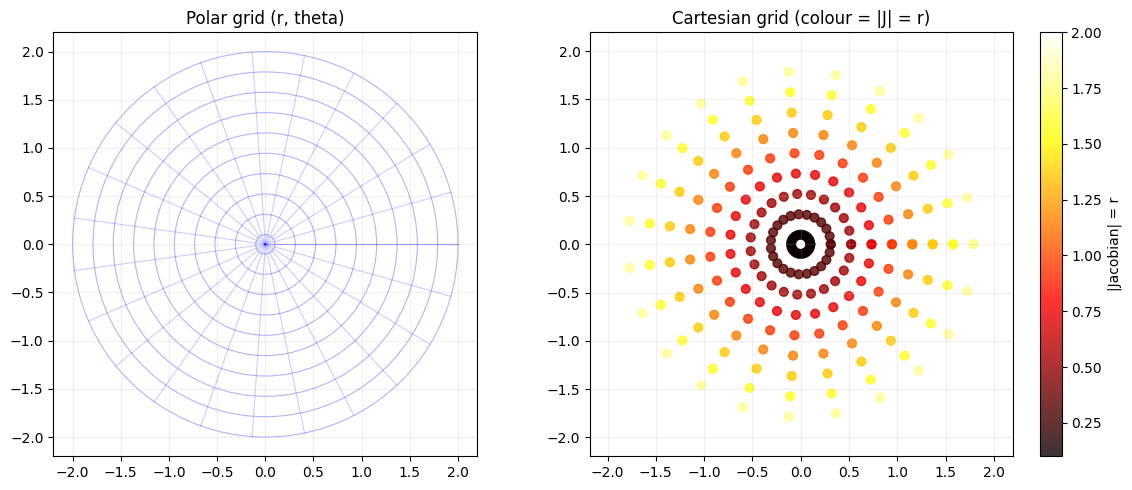

In [3]:
# Visualise Jacobian determinant of a 2D transformation
# f(r, theta) = (r*cos(theta), r*sin(theta))  [polar to Cartesian]
# |J| = r (area element in polar coords)

r_vals = np.linspace(0.1, 2.0, 10)
theta_vals = np.linspace(0, 2*np.pi, 24)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grid in polar space
ax = axes[0]
for r in r_vals:
    ax.add_patch(plt.Circle((0, 0), r, fill=False, color='blue', alpha=0.3, lw=0.8))
for t in theta_vals:
    ax.plot([0, 2*np.cos(t)], [0, 2*np.sin(t)], 'b-', alpha=0.2, lw=0.8)
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect('equal')
ax.set_title('Polar grid (r, theta)'); ax.grid(True, alpha=0.2)

# Jacobian determinant = r at each grid point
R, THETA = np.meshgrid(r_vals, theta_vals)
X_cart = R * np.cos(THETA); Y_cart = R * np.sin(THETA)
axes[1].scatter(X_cart, Y_cart, c=R, cmap='hot', s=40, alpha=0.8)
axes[1].set_aspect('equal'); axes[1].set_title('Cartesian grid (colour = |J| = r)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='|Jacobian| = r')
axes[1].grid(True, alpha=0.2)
plt.tight_layout(); plt.savefig('ch237_jacobian.png', dpi=100); plt.show()


## Summary

| Concept | Size | Role |
|---|---|---|
| Gradient | (d,) | Derivative of scalar-output function |
| Jacobian | (m, n) | Derivative of vector-output function |
| VJP (J^T v) | (n,) | Efficient backprop primitive |
| |J| (det) | Scalar | Volume scaling — change of variables |

**Forward reference:** ch292 — Clustering and ch293 — Classification (Part IX) use learned transformations whose Jacobians determine how information is preserved.